In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/Chemit797/PepADMET-Dataset/main/PEPlife/PEPlife_half_life_all.csv"

df = pd.read_csv(url)

df_clean = df[["SEQUENCE", "Converted Half-life(seconds)"]].copy()
df_clean.columns = ["sequence", "half_life"]

df_clean = df_clean.dropna()

df_clean["sequence"] = (
    df_clean["sequence"]
    .astype(str)
    .str.upper()
    .str.strip()
)

standard_aa = set("ACDEFGHIKLMNPQRSTVWY")

def is_valid_peptide(seq):
    return all(aa in standard_aa for aa in seq)

df_clean = df_clean[df_clean["sequence"].apply(is_valid_peptide)]

df_clean = df_clean[
    df_clean["sequence"].apply(lambda x: 5 <= len(x) <= 50)
]

df_clean = df_clean.drop_duplicates(subset="sequence")
df_clean = df_clean.reset_index(drop=True)

print("Clean dataset shape:", df_clean.shape)
df_clean.head()

Clean dataset shape: (722, 2)


,sequence,half_life
0,AAGIGILTV,22.0000
1,GSIGAASMEF,2.7013
2,IGAASMEFCF,0.0629
3,AASMEFCFDV,0.0556
4,SMEFCFDVFK,0.0103


In [2]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel

model_name = "facebook/esm2_t6_8M_UR50D"

tokenizer = AutoTokenizer.from_pretrained(model_name)
esm_model = AutoModel.from_pretrained(model_name)

esm_model.eval()

def get_embedding(sequence):
    inputs = tokenizer(
        sequence,
        return_tensors="pt",
        padding=False,
        truncation=False
    )

    with torch.no_grad():
        outputs = esm_model(**inputs)

    embedding = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
    return embedding

D:\anaconda\envs\peptide_ml\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\anaconda\envs\peptide_ml\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
W0430 14:06:10.538000 18464 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [3]:
from tqdm import tqdm

embeddings = []

for seq in tqdm(df_clean["sequence"]):
    emb = get_embedding(seq)
    embeddings.append(emb)

X = np.array(embeddings)
y = df_clean["half_life"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

100%|██████████| 722/722 [00:07<00:00, 95.23it/s] 

X shape: (722, 320)
y shape: (722,)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

y_log = np.log10(y + 1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

half_life_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

half_life_model.fit(X_train, y_train)

pred_test = half_life_model.predict(X_test)

mae = mean_absolute_error(y_test, pred_test)
r2 = r2_score(y_test, pred_test)

print("MAE:", mae)
print("R2:", r2)

MAE: 0.5909680190636887
R2: 0.7001562712844287


In [5]:
import joblib

joblib.dump(half_life_model, "hl_model.pkl")

np.save("X_esm2.npy", X)
np.save("y_hl.npy", y)

df_clean.to_csv("hl_clean_data.csv", index=False)

In [6]:
bpc157_sequence = "GEPPPGKPADDAGLV"
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

mutants = []

for pos, original_aa in enumerate(bpc157_sequence, start=1):
    for new_aa in amino_acids:
        if new_aa == original_aa:
            continue

        mutant_sequence = (
            bpc157_sequence[:pos - 1]
            + new_aa
            + bpc157_sequence[pos:]
        )

        mutants.append({
            "id": f"BPC157_{original_aa}{pos}{new_aa}",
            "position": pos,
            "original_aa": original_aa,
            "mutated_aa": new_aa,
            "mutant_sequence": mutant_sequence
        })

df_mutants = pd.DataFrame(mutants)

print("Number of mutants:", len(df_mutants))
df_mutants.head()

Number of mutants: 285


,id,position,original_aa,mutated_aa,mutant_sequence
0,BPC157_G1A,1,G,A,AEPPPGKPADDAGLV
1,BPC157_G1C,1,G,C,CEPPPGKPADDAGLV
2,BPC157_G1D,1,G,D,DEPPPGKPADDAGLV
3,BPC157_G1E,1,G,E,EEPPPGKPADDAGLV
4,BPC157_G1F,1,G,F,FEPPPGKPADDAGLV


In [7]:
mutant_embeddings = []

for seq in tqdm(df_mutants["mutant_sequence"]):
    emb = get_embedding(seq)
    mutant_embeddings.append(emb)

X_mutants = np.array(mutant_embeddings)

pred_log = half_life_model.predict(X_mutants)

pred_half_life_seconds = (10 ** pred_log) - 1

df_ranked = df_mutants.copy()
df_ranked["pred_half_life_seconds"] = pred_half_life_seconds
df_ranked["pred_half_life_minutes"] = df_ranked["pred_half_life_seconds"] / 60

df_ranked = df_ranked.sort_values(
    "pred_half_life_seconds",
    ascending=False
).reset_index(drop=True)

df_ranked.to_csv("bpc157_mutants_hl.csv", index=False)

df_ranked.head(10)

100%|██████████| 285/285 [00:02<00:00, 112.53it/s]


,id,position,original_aa,mutated_aa,mutant_sequence,pred_half_life_seconds,pred_half_life_minutes
0,BPC157_G6P,6,G,P,GEPPPPKPADDAGLV,2244.354360,37.405906
1,BPC157_G1P,1,G,P,PEPPPGKPADDAGLV,2179.545922,36.325765
2,BPC157_G6E,6,G,E,GEPPPEKPADDAGLV,2127.190113,35.453169
3,BPC157_G1T,1,G,T,TEPPPGKPADDAGLV,2002.162009,33.369367
4,BPC157_G6T,6,G,T,GEPPPTKPADDAGLV,1974.249656,32.904161
5,BPC157_G1E,1,G,E,EEPPPGKPADDAGLV,1889.930265,31.498838
6,BPC157_V15W,15,V,W,GEPPPGKPADDAGLW,1847.292755,30.788213
7,BPC157_A12P,12,A,P,GEPPPGKPADDPGLV,1777.415696,29.623595
8,BPC157_L14W,14,L,W,GEPPPGKPADDAGWV,1736.836250,28.947271
9,BPC157_V15H,15,V,H,GEPPPGKPADDAGLH,1727.546543,28.792442


In [8]:
with open("bpc157_mutants.fasta", "w") as f:
    for _, row in df_ranked.iterrows():
        f.write(f">{row['id']}\n")
        f.write(f"{row['mutant_sequence']}\n")

In [9]:
!toxinpred3 -i bpc157_mutants.fasta -o toxinpred3_results.csv -m 1 -d 2

"toxinpred3" не является внутренней или внешней
командой, исполняемой программой или пакетным файлом.


In [10]:
tox = pd.read_csv("toxinpred3_results.csv")

tox_small = tox[["ID", "ML Score", "Prediction", "PPV"]].copy()

tox_small.columns = [
    "id",
    "toxicity_score",
    "toxicity_prediction",
    "toxicity_ppv"
]

df_ranked_tox = df_ranked.merge(
    tox_small,
    on="id",
    how="left"
)

df_ranked_tox.head()

,id,position,original_aa,mutated_aa,mutant_sequence,pred_half_life_seconds,pred_half_life_minutes,toxicity_score,toxicity_prediction,toxicity_ppv
0,BPC157_G6P,6,G,P,GEPPPPKPADDAGLV,2244.354360,37.405906,0.105,Non-Toxin,0.011380
1,BPC157_G1P,1,G,P,PEPPPGKPADDAGLV,2179.545922,36.325765,0.160,Non-Toxin,0.079256
2,BPC157_G6E,6,G,E,GEPPPEKPADDAGLV,2127.190113,35.453169,0.095,Non-Toxin,0.000000
3,BPC157_G1T,1,G,T,TEPPPGKPADDAGLV,2002.162009,33.369367,0.120,Non-Toxin,0.029892
4,BPC157_G6T,6,G,T,GEPPPTKPADDAGLV,1974.249656,32.904161,0.100,Non-Toxin,0.005210


In [11]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis

def calculate_solubility_features(seq):
    analyzed = ProteinAnalysis(seq)

    return {
        "molecular_weight": analyzed.molecular_weight(),
        "gravy": analyzed.gravy(),
        "aromaticity": analyzed.aromaticity(),
        "instability_index": analyzed.instability_index(),
        "isoelectric_point": analyzed.isoelectric_point(),
        "charge_pH7": analyzed.charge_at_pH(7.0)
    }

features = df_ranked_tox["mutant_sequence"].apply(calculate_solubility_features)
features_df = pd.DataFrame(list(features))

df_ranked_sol = pd.concat(
    [df_ranked_tox.reset_index(drop=True), features_df],
    axis=1
)

df_ranked_sol["solubility_score"] = (
    -df_ranked_sol["gravy"]
    + 0.1 * abs(df_ranked_sol["charge_pH7"])
    - 0.01 * df_ranked_sol["aromaticity"]
)

df_ranked_sol.head()

,id,position,original_aa,mutated_aa,mutant_sequence,pred_half_life_seconds,pred_half_life_minutes,toxicity_score,toxicity_prediction,toxicity_ppv,molecular_weight,gravy,aromaticity,instability_index,isoelectric_point,charge_pH7,solubility_score
0,BPC157_G6P,6,G,P,GEPPPPKPADDAGLV,2244.354360,37.405906,0.105,Non-Toxin,0.011380,1459.5994,-0.773333,0.0,57.820000,4.050028,-2.235845,0.996918
1,BPC157_G1P,1,G,P,PEPPPGKPADDAGLV,2179.545922,36.325765,0.160,Non-Toxin,0.079256,1459.5994,-0.773333,0.0,55.933333,4.050028,-2.037418,0.977075
2,BPC157_G6E,6,G,E,GEPPPEKPADDAGLV,2127.190113,35.453169,0.095,Non-Toxin,0.000000,1491.5982,-0.900000,0.0,56.566667,4.050028,-3.233035,1.223303
3,BPC157_G1T,1,G,T,TEPPPGKPADDAGLV,2002.162009,33.369367,0.120,Non-Toxin,0.029892,1463.5881,-0.713333,0.0,57.186667,4.050028,-2.597750,0.973108
4,BPC157_G6T,6,G,T,GEPPPTKPADDAGLV,1974.249656,32.904161,0.100,Non-Toxin,0.005210,1463.5881,-0.713333,0.0,44.980000,4.050028,-2.235845,0.936918


In [12]:
def proteolysis_score(seq):
    score = 0
    sites = []

    for i in range(len(seq) - 1):
        if seq[i] in ["K", "R"] and seq[i + 1] != "P":
            score += 1
            sites.append(f"Trypsin:{seq[i]}{i + 1}")

    for i in range(len(seq) - 1):
        if seq[i] in ["F", "W", "Y", "L"] and seq[i + 1] != "P":
            score += 1
            sites.append(f"Chymotrypsin:{seq[i]}{i + 1}")

    for i in range(len(seq) - 1):
        if seq[i] in ["A", "G", "S", "V"]:
            score += 1
            sites.append(f"Elastase-like:{seq[i]}{i + 1}")

    return score, "; ".join(sites)

proteolysis_results = df_ranked_sol["mutant_sequence"].apply(proteolysis_score)

df_ranked_sol["proteolysis_score"] = proteolysis_results.apply(lambda x: x[0])
df_ranked_sol["proteolysis_sites"] = proteolysis_results.apply(lambda x: x[1])

df_ranked_sol.head()

,id,position,original_aa,mutated_aa,mutant_sequence,pred_half_life_seconds,pred_half_life_minutes,toxicity_score,toxicity_prediction,toxicity_ppv,molecular_weight,gravy,aromaticity,instability_index,isoelectric_point,charge_pH7,solubility_score,proteolysis_score,proteolysis_sites
0,BPC157_G6P,6,G,P,GEPPPPKPADDAGLV,2244.354360,37.405906,0.105,Non-Toxin,0.011380,1459.5994,-0.773333,0.0,57.820000,4.050028,-2.235845,0.996918,5,Chymotrypsin:L14; Elastase-like:G1; Elastase-l...
1,BPC157_G1P,1,G,P,PEPPPGKPADDAGLV,2179.545922,36.325765,0.160,Non-Toxin,0.079256,1459.5994,-0.773333,0.0,55.933333,4.050028,-2.037418,0.977075,5,Chymotrypsin:L14; Elastase-like:G6; Elastase-l...
2,BPC157_G6E,6,G,E,GEPPPEKPADDAGLV,2127.190113,35.453169,0.095,Non-Toxin,0.000000,1491.5982,-0.900000,0.0,56.566667,4.050028,-3.233035,1.223303,5,Chymotrypsin:L14; Elastase-like:G1; Elastase-l...
3,BPC157_G1T,1,G,T,TEPPPGKPADDAGLV,2002.162009,33.369367,0.120,Non-Toxin,0.029892,1463.5881,-0.713333,0.0,57.186667,4.050028,-2.597750,0.973108,5,Chymotrypsin:L14; Elastase-like:G6; Elastase-l...
4,BPC157_G6T,6,G,T,GEPPPTKPADDAGLV,1974.249656,32.904161,0.100,Non-Toxin,0.005210,1463.5881,-0.713333,0.0,44.980000,4.050028,-2.235845,0.936918,5,Chymotrypsin:L14; Elastase-like:G1; Elastase-l...


In [13]:
def aggregation_score(seq):
    aggregation_prone_aa = set("FWYVIL")

    hydrophobic_count = sum(aa in aggregation_prone_aa for aa in seq)
    aromatic_count = sum(aa in "FWY" for aa in seq)
    proline_count = seq.count("P")

    score = (
        hydrophobic_count
        + 2 * aromatic_count
        - 0.5 * proline_count
    )

    return score

df_ranked_sol["aggregation_score"] = (
    df_ranked_sol["mutant_sequence"].apply(aggregation_score)
)

df_ranked_sol.head()

,id,position,original_aa,mutated_aa,mutant_sequence,pred_half_life_seconds,pred_half_life_minutes,toxicity_score,toxicity_prediction,toxicity_ppv,molecular_weight,gravy,aromaticity,instability_index,isoelectric_point,charge_pH7,solubility_score,proteolysis_score,proteolysis_sites,aggregation_score
0,BPC157_G6P,6,G,P,GEPPPPKPADDAGLV,2244.354360,37.405906,0.105,Non-Toxin,0.011380,1459.5994,-0.773333,0.0,57.820000,4.050028,-2.235845,0.996918,5,Chymotrypsin:L14; Elastase-like:G1; Elastase-l...,-0.5
1,BPC157_G1P,1,G,P,PEPPPGKPADDAGLV,2179.545922,36.325765,0.160,Non-Toxin,0.079256,1459.5994,-0.773333,0.0,55.933333,4.050028,-2.037418,0.977075,5,Chymotrypsin:L14; Elastase-like:G6; Elastase-l...,-0.5
2,BPC157_G6E,6,G,E,GEPPPEKPADDAGLV,2127.190113,35.453169,0.095,Non-Toxin,0.000000,1491.5982,-0.900000,0.0,56.566667,4.050028,-3.233035,1.223303,5,Chymotrypsin:L14; Elastase-like:G1; Elastase-l...,0.0
3,BPC157_G1T,1,G,T,TEPPPGKPADDAGLV,2002.162009,33.369367,0.120,Non-Toxin,0.029892,1463.5881,-0.713333,0.0,57.186667,4.050028,-2.597750,0.973108,5,Chymotrypsin:L14; Elastase-like:G6; Elastase-l...,0.0
4,BPC157_G6T,6,G,T,GEPPPTKPADDAGLV,1974.249656,32.904161,0.100,Non-Toxin,0.005210,1463.5881,-0.713333,0.0,44.980000,4.050028,-2.235845,0.936918,5,Chymotrypsin:L14; Elastase-like:G1; Elastase-l...,0.0


In [14]:
df_selection = df_ranked_sol[
    df_ranked_sol["toxicity_prediction"] == "Non-Toxin"
].copy()

df_selection["half_life_norm"] = (
    (df_selection["pred_half_life_seconds"] - df_selection["pred_half_life_seconds"].min()) /
    (df_selection["pred_half_life_seconds"].max() - df_selection["pred_half_life_seconds"].min())
)

df_selection["solubility_norm"] = (
    (df_selection["solubility_score"] - df_selection["solubility_score"].min()) /
    (df_selection["solubility_score"].max() - df_selection["solubility_score"].min())
)

df_selection["proteolysis_norm"] = 1 - (
    (df_selection["proteolysis_score"] - df_selection["proteolysis_score"].min()) /
    (df_selection["proteolysis_score"].max() - df_selection["proteolysis_score"].min())
)

df_selection["aggregation_norm"] = 1 - (
    (df_selection["aggregation_score"] - df_selection["aggregation_score"].min()) /
    (df_selection["aggregation_score"].max() - df_selection["aggregation_score"].min())
)

df_selection["final_score"] = (
    0.55 * df_selection["half_life_norm"] +
    0.20 * df_selection["solubility_norm"] +
    0.15 * df_selection["proteolysis_norm"] +
    0.10 * df_selection["aggregation_norm"]
)

df_selection = df_selection.sort_values(
    "final_score",
    ascending=False
).reset_index(drop=True)

df_selection[[
    "id",
    "mutant_sequence",
    "pred_half_life_seconds",
    "pred_half_life_minutes",
    "toxicity_prediction",
    "solubility_score",
    "proteolysis_score",
    "aggregation_score",
    "final_score"
]].head(10)

,id,mutant_sequence,pred_half_life_seconds,pred_half_life_minutes,toxicity_prediction,solubility_score,proteolysis_score,aggregation_score,final_score
0,BPC157_G6P,GEPPPPKPADDAGLV,2244.354360,37.405906,Non-Toxin,0.996918,5,-0.5,0.894470
1,BPC157_G6E,GEPPPEKPADDAGLV,2127.190113,35.453169,Non-Toxin,1.223303,5,0.0,0.891892
2,BPC157_G1P,PEPPPGKPADDAGLV,2179.545922,36.325765,Non-Toxin,0.977075,5,-0.5,0.875293
3,BPC157_G1E,EEPPPGKPADDAGLV,1889.930265,31.498838,Non-Toxin,1.215912,5,0.0,0.832158
4,BPC157_L14P,GEPPPGKPADDAGPV,1716.642864,28.610714,Non-Toxin,1.276918,5,-1.5,0.829188
5,BPC157_L14D,GEPPPGKPADDAGDV,1596.134898,26.602248,Non-Toxin,1.503472,5,-1.0,0.825812
6,BPC157_G1T,TEPPPGKPADDAGLV,2002.162009,33.369367,Non-Toxin,0.973108,5,0.0,0.820884
7,BPC157_G6T,GEPPPTKPADDAGLV,1974.249656,32.904161,Non-Toxin,0.936918,5,0.0,0.808188
8,BPC157_A12P,GEPPPGKPADDPGLV,1777.415696,29.623595,Non-Toxin,1.143585,5,-0.5,0.802785
9,BPC157_V15P,GEPPPGKPADDAGLP,1585.795317,26.429922,Non-Toxin,1.303585,5,-1.5,0.801179


In [15]:
df_selection.to_csv(
    "bpc157_final_candidate_ranking.csv",
    index=False
)

df_selection.head(20).to_csv(
    "bpc157_top20_candidates.csv",
    index=False
)

df_selection.head(5).to_csv(
    "bpc157_top5_candidates.csv",
    index=False
)

In [16]:
original_seq = "GEPPPGKPADDAGLV"

orig_emb = get_embedding(original_seq).reshape(1, -1)
orig_log = half_life_model.predict(orig_emb)
orig_half_life = (10 ** orig_log)[0] - 1

analysis = ProteinAnalysis(original_seq)
orig_solubility = (
    -analysis.gravy()
    + 0.1 * abs(analysis.charge_at_pH(7.0))
    - 0.01 * analysis.aromaticity()
)

orig_prot_score = proteolysis_score(original_seq)[0]

orig_agg_score = aggregation_score(original_seq)

original_data = {
    "id": "BPC157_original",
    "mutant_sequence": original_seq,
    "pred_half_life_seconds": orig_half_life,
    "solubility_score": orig_solubility,
    "proteolysis_score": orig_prot_score,
    "aggregation_score": orig_agg_score
}

df_original = pd.DataFrame([original_data])

df_original

,id,mutant_sequence,pred_half_life_seconds,solubility_score,proteolysis_score,aggregation_score
0,BPC157_original,GEPPPGKPADDAGLV,975.575163,0.916918,6,0.0


In [17]:
df_compare = pd.concat([
    df_original,
    df_selection.head(5)
]).reset_index(drop=True)

df_compare

,id,mutant_sequence,pred_half_life_seconds,solubility_score,proteolysis_score,aggregation_score,position,original_aa,mutated_aa,pred_half_life_minutes,...,aromaticity,instability_index,isoelectric_point,charge_pH7,proteolysis_sites,half_life_norm,solubility_norm,proteolysis_norm,aggregation_norm,final_score
0,BPC157_original,GEPPPGKPADDAGLV,975.575163,0.916918,6,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BPC157_G6P,GEPPPPKPADDAGLV,2244.354360,0.996918,5,-0.5,6.0,G,P,37.405906,...,0.0,57.820000,4.050028,-2.235845,Chymotrypsin:L14; Elastase-like:G1; Elastase-l...,1.000000,0.572352,1.0,0.8,0.894470
2,BPC157_G6E,GEPPPEKPADDAGLV,2127.190113,1.223303,5,0.0,6.0,G,E,35.453169,...,0.0,56.566667,4.050028,-3.233035,Chymotrypsin:L14; Elastase-like:G1; Elastase-l...,0.947432,0.754023,1.0,0.7,0.891892
3,BPC157_G1P,PEPPPGKPADDAGLV,2179.545922,0.977075,5,-0.5,1.0,G,P,36.325765,...,0.0,55.933333,4.050028,-2.037418,Chymotrypsin:L14; Elastase-like:G6; Elastase-l...,0.970923,0.556428,1.0,0.8,0.875293
4,BPC157_G1E,EEPPPGKPADDAGLV,1889.930265,1.215912,5,0.0,1.0,G,E,31.498838,...,0.0,66.080000,4.050028,-3.159119,Chymotrypsin:L14; Elastase-like:G6; Elastase-l...,0.840982,0.748092,1.0,0.7,0.832158
5,BPC157_L14P,GEPPPGKPADDAGPV,1716.642864,1.276918,5,-1.5,14.0,L,P,28.610714,...,0.0,52.160000,4.050028,-2.235845,Elastase-like:G1; Elastase-like:G6; Elastase-l...,0.763234,0.797048,1.0,1.0,0.829188


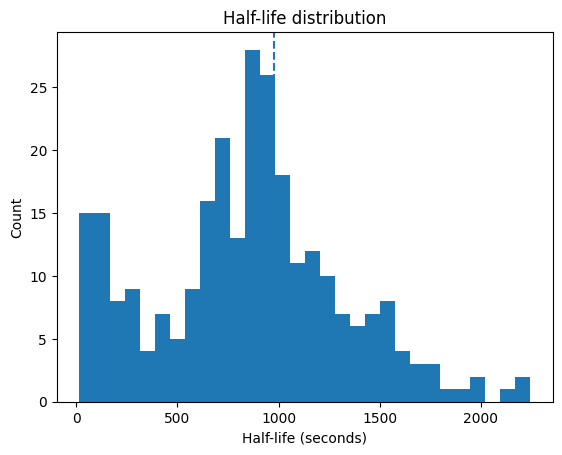

In [18]:
import matplotlib.pyplot as plt

plt.figure()

plt.hist(df_selection["pred_half_life_seconds"], bins=30)
plt.axvline(orig_half_life, linestyle='--')

plt.title("Half-life distribution")
plt.xlabel("Half-life (seconds)")
plt.ylabel("Count")

plt.show()

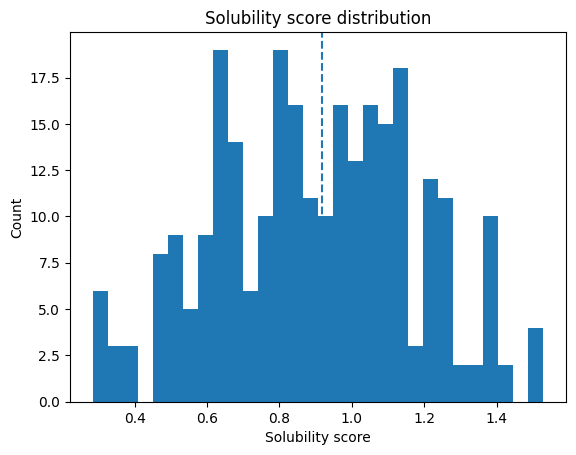

In [19]:
plt.figure()

plt.hist(df_selection["solubility_score"], bins=30)
plt.axvline(orig_solubility, linestyle='--')

plt.title("Solubility score distribution")
plt.xlabel("Solubility score")
plt.ylabel("Count")

plt.show()

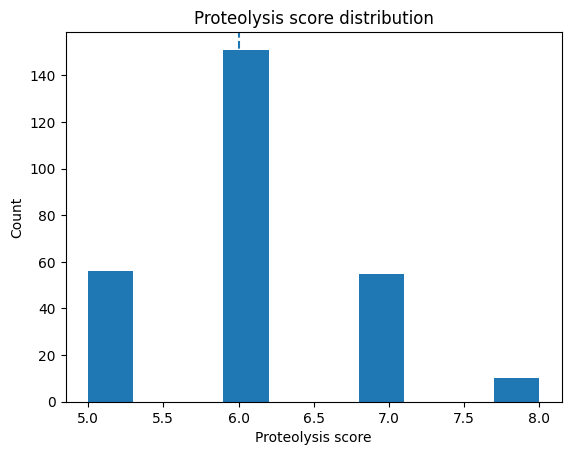

In [20]:
plt.figure()

plt.hist(df_selection["proteolysis_score"], bins=10)
plt.axvline(orig_prot_score, linestyle='--')

plt.title("Proteolysis score distribution")
plt.xlabel("Proteolysis score")
plt.ylabel("Count")

plt.show()

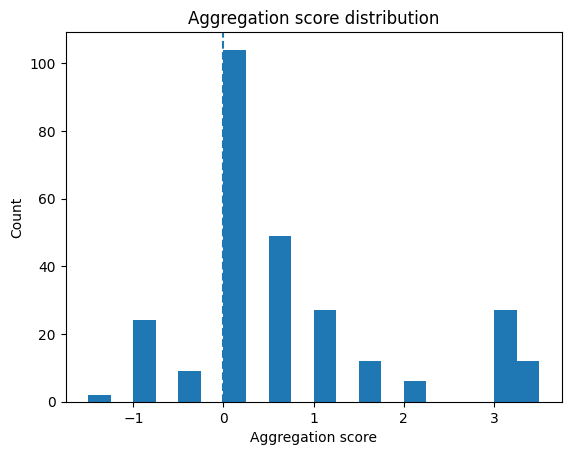

In [21]:
plt.figure()

plt.hist(df_selection["aggregation_score"], bins=20)
plt.axvline(orig_agg_score, linestyle='--')

plt.title("Aggregation score distribution")
plt.xlabel("Aggregation score")
plt.ylabel("Count")

plt.show()